# 05 — Part F: Hyperparameter Optimisation (Logistic Regression, Random Forest)

**6001CEM Machine Learning Group Project — Diabetes 130-US Hospitals Readmission Prediction**
**Owner: Person A**

**Inputs:**
- `../data/processed/train_clean_selected.csv`, `../data/processed/test_clean_selected.csv` (Part D outputs)
- `../data/raw/diabetic_data.csv` (used only to reconstruct `patient_nbr` for grouped CV — see note below)

**Methodology note (read before running):**
D021's imbalance-strategy CV comparison used plain `StratifiedKFold`, because `patient_nbr`
is not present in `train_clean_selected.csv` (dropped per D006/D019) — a documented
limitation in D021. D022 (XGBoost tuning) fixed this by reconstructing `patient_nbr` for the
training rows and using `StratifiedGroupKFold`. This notebook reuses that exact reconstruction
so all three models' Part F results are methodologically consistent and directly comparable
in the report and in Part H.

**Locked-in decisions carried over (not re-tested here):**
- Imbalance handling strategy for both models is `class_weight` (D021) — the *weighting scheme*
  is tuned/extended below (e.g. RF's `balanced` vs `balanced_subsample`), but "no adjustment" and
  "SMOTE" are not re-tested; D021 already settled that comparison.
- Primary scoring metric is PR-AUC (average precision), matching D021/D022 — ROC-AUC is a weaker
  signal at 11.16% positive-class prevalence (D009).

**Caveat to state explicitly in the report (same as D022):** this notebook's CV PR-AUC (grouped)
is not a clean "before/after" against D021's CV PR-AUC (ungrouped) for the same model + strategy.
The two are not directly comparable — report both numbers with that caveat rather than presenting
a bare delta.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, GroupShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import loguniform, uniform

import joblib

RANDOM_STATE = 42

## 1. Reconstruct `patient_nbr` for Grouped CV

Reproduces the exact D016 cleaning + split logic (same `RANDOM_STATE`) so the reconstructed
`patient_nbr` array lines up 1:1 with the rows in `train_clean_selected.csv`. This is copied
directly from `04_XGBoost_Advanced.ipynb` rather than re-derived, to guarantee the same grouping
is used across all three models' Part F work.

In [2]:
# Reproduce the Part D cleaning steps needed to get patient_nbr aligned with train_clean_selected.csv
raw = pd.read_csv("../data/raw/diabetic_data.csv")
raw = raw.replace("?", np.nan)
raw = raw[raw["gender"] != "Unknown/Invalid"].copy()
raw["readmitted_30"] = (raw["readmitted"] == "<30").astype(int)

X_raw = raw.drop(columns=["readmitted_30"])
y_raw = raw["readmitted_30"]
groups_raw = raw["patient_nbr"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_raw, y_raw, groups=groups_raw))

patient_nbr_train = raw.iloc[train_idx]["patient_nbr"].reset_index(drop=True)

print("Reconstructed training patient_nbr array length:", len(patient_nbr_train))

Reconstructed training patient_nbr array length: 81526


In [3]:
# Load the actual feature-selected data and verify alignment
train_df = pd.read_csv("../data/processed/train_clean_selected.csv")
test_df = pd.read_csv("../data/processed/test_clean_selected.csv")

TARGET = "readmitted_30"

assert len(train_df) == len(patient_nbr_train), (
    "Row count mismatch — reconstructed split does not match train_clean_selected.csv. "
    "Check RANDOM_STATE and cleaning steps match 02_Data_Preprocessing.ipynb exactly."
)

# Sanity check: target values in the reconstructed order should match train_df's target
reconstructed_target = raw.iloc[train_idx][TARGET].reset_index(drop=True)
assert (reconstructed_target.values == train_df[TARGET].values).all(), (
    "Target mismatch — row order does not align. Do not proceed with grouped CV until this passes."
)

print("PASS: reconstructed patient_nbr aligns with train_clean_selected.csv row order.")
print("Unique patients in training set:", patient_nbr_train.nunique())

PASS: reconstructed patient_nbr aligns with train_clean_selected.csv row order.
Unique patients in training set: 57175


In [4]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (81526, 45), X_test: (20237, 45)


## 2. Logistic Regression — Hyperparameter Search

`class_weight='balanced'` is locked in per D021 and not re-tested. The search covers `C`
(regularisation strength, log-uniform) and `penalty` (`l1`/`l2`/`elasticnet`). This is a
meaningful methodological choice, not just a tuning knob: L1 (and the L1 component of
elasticnet) drives coefficients of weak predictors to exactly zero, offering a further,
model-internal sparsity/feature-selection effect on top of D019's near-zero-variance removal
— and, per D020's interpretability argument, a sparser coefficient set is easier to attribute
to specific named clinical factors. `solver='saga'` is used throughout (rather than switching
solver per penalty) so the search space stays uniform; this trades some convergence speed for
simplicity, which is acceptable given `RandomizedSearchCV` caps the total number of fits.

In [5]:
lr_param_dist = {
    "C": loguniform(1e-3, 1e2),
    "penalty": ["l1", "l2", "elasticnet"],
    "l1_ratio": uniform(0, 1),  # only used when penalty == 'elasticnet'; ignored otherwise
}

lr_base = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

lr_search = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=lr_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

lr_search.fit(X_train, y_train, groups=patient_nbr_train)

print("Best CV PR-AUC (LR):", lr_search.best_score_)
print("Best params (LR):")
for k, v in lr_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Best CV PR-AUC (LR): 0.19254161527087926
Best params (LR):
  C: 0.011526449540315618
  l1_ratio: 0.18182496720710062
  penalty: l1


In [6]:
lr_baseline_prauc = 0.1918  # D021, Logistic Regression + class_weight, untuned, plain StratifiedKFold
lr_tuned_prauc = lr_search.best_score_

print(f"D021 baseline (untuned, ungrouped CV): PR-AUC = {lr_baseline_prauc:.4f}")
print(f"This search (tuned, grouped CV):       PR-AUC = {lr_tuned_prauc:.4f}")
print(f"Difference: {lr_tuned_prauc - lr_baseline_prauc:+.4f}")
print()
print("Note for report: these two numbers are not perfectly comparable — this search used grouped CV")
print("(more conservative/realistic), the D021 baseline used ungrouped CV. State this explicitly rather")
print("than presenting the raw delta as a clean before/after tuning effect.")

D021 baseline (untuned, ungrouped CV): PR-AUC = 0.1918
This search (tuned, grouped CV):       PR-AUC = 0.1925
Difference: +0.0007

Note for report: these two numbers are not perfectly comparable — this search used grouped CV
(more conservative/realistic), the D021 baseline used ungrouped CV. State this explicitly rather
than presenting the raw delta as a clean before/after tuning effect.


## 3. Random Forest — Hyperparameter Search

`class_weight` search includes both `'balanced'` (D021's tested value) and
`'balanced_subsample'` (not tested in D021). `balanced_subsample` recomputes class weights
separately for each bootstrap sample rather than once on the full training set — given D021
already flagged Random Forest as the weakest of the three candidate models under `class_weight`,
this closes a real gap left open by D021 rather than simply re-confirming its choice.

In [7]:
from scipy.stats import randint

rf_param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train, groups=patient_nbr_train)

print("Best CV PR-AUC (RF):", rf_search.best_score_)
print("Best params (RF):")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV PR-AUC (RF): 0.19555392254156811
Best params (RF):
  class_weight: balanced
  max_depth: 5
  max_features: 0.5
  min_samples_leaf: 9
  min_samples_split: 15
  n_estimators: 341


In [8]:
rf_baseline_prauc = 0.1271  # D021, Random Forest + class_weight, untuned, plain StratifiedKFold
rf_tuned_prauc = rf_search.best_score_

print(f"D021 baseline (untuned, ungrouped CV): PR-AUC = {rf_baseline_prauc:.4f}")
print(f"This search (tuned, grouped CV):       PR-AUC = {rf_tuned_prauc:.4f}")
print(f"Difference: {rf_tuned_prauc - rf_baseline_prauc:+.4f}")
print()
print("Note: D021 flagged RF as the weakest of the three candidate models under class_weight")
print("(PR-AUC dropped from 0.1440 'none' to 0.1271 'class_weight'). If tuning does not close this")
print("gap relative to LR/XGBoost, state that plainly per the report's experimental-results policy —")
print("do not understate a negative or marginal result (Section 23 / D021).")

D021 baseline (untuned, ungrouped CV): PR-AUC = 0.1271
This search (tuned, grouped CV):       PR-AUC = 0.1956
Difference: +0.0685

Note: D021 flagged RF as the weakest of the three candidate models under class_weight
(PR-AUC dropped from 0.1440 'none' to 0.1271 'class_weight'). If tuning does not close this
gap relative to LR/XGBoost, state that plainly per the report's experimental-results policy —
do not understate a negative or marginal result (Section 23 / D021).


## 4. Threshold Tuning and Held-Out Test Evaluation

Matches D022's approach: an internal validation split (via `GroupShuffleSplit`, grouped by
`patient_nbr` to avoid leaking a patient's encounters across the fit/validation boundary) is
used to tune the decision threshold via F2 score (recall weighted 2:1 over precision) — the
same healthcare justification D022 uses (a missed readmission is treated as costlier than an
unnecessary follow-up). The held-out test set is touched only once, at the end, for each model.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


--- Logistic Regression: threshold tuning (validation set) ---
Threshold maximising F2: 0.4351  (precision=0.1319, recall=0.7902)


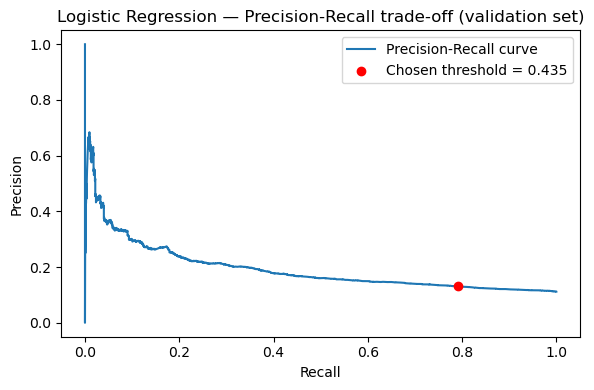

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


--- Logistic Regression: Default threshold (0.5) ---
PR-AUC:    0.1915
ROC-AUC:   0.6266
Precision: 0.1709
Recall:    0.4352
F1:        0.2454

--- Logistic Regression: Tuned threshold (0.435) ---
PR-AUC:    0.1915
ROC-AUC:   0.6266
Precision: 0.1288
Recall:    0.7904
F1:        0.2216



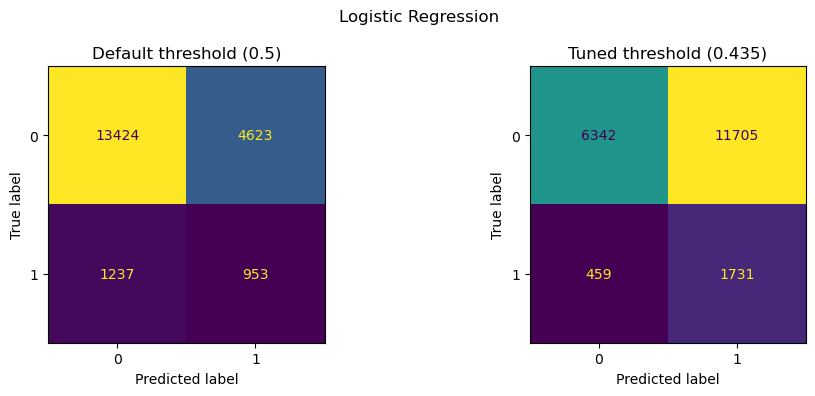

In [9]:
def tune_and_evaluate(name, search, X_train, y_train, X_test, y_test, groups):
    """Refit the search's best estimator, tune decision threshold on a grouped validation
    split (F2), and evaluate once on the held-out test set."""
    best_params = search.best_params_

    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    fit_idx, val_idx = next(gss.split(X_train, y_train, groups=groups))
    X_fit, X_val = X_train.iloc[fit_idx], X_train.iloc[val_idx]
    y_fit, y_val = y_train.iloc[fit_idx], y_train.iloc[val_idx]

    model = search.estimator.__class__(**{**search.estimator.get_params(), **best_params})
    model.fit(X_fit, y_fit)

    val_proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
    beta = 2
    f2_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)
    best_idx = np.argmax(f2_scores[:-1])
    best_threshold = thresholds[best_idx]

    print(f"--- {name}: threshold tuning (validation set) ---")
    print(f"Threshold maximising F2: {best_threshold:.4f}  "
          f"(precision={precisions[best_idx]:.4f}, recall={recalls[best_idx]:.4f})")

    plt.figure(figsize=(6, 4))
    plt.plot(recalls, precisions, label="Precision-Recall curve")
    plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5,
                label=f"Chosen threshold = {best_threshold:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{name} — Precision-Recall trade-off (validation set)")
    plt.legend(); plt.tight_layout(); plt.show()

    # Refit on the FULL training set for the final model, per D022's convention
    final_model = search.estimator.__class__(**{**search.estimator.get_params(), **best_params})
    final_model.fit(X_train, y_train)

    test_proba = final_model.predict_proba(X_test)[:, 1]
    test_pred_default = (test_proba >= 0.5).astype(int)
    test_pred_tuned = (test_proba >= best_threshold).astype(int)

    def report_metrics(y_true, y_pred, y_proba, label):
        print(f"--- {name}: {label} ---")
        print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
        print(f"Precision: {precision_score(y_true, y_pred):.4f}")
        print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
        print(f"F1:        {f1_score(y_true, y_pred):.4f}")
        print()

    report_metrics(y_test, test_pred_default, test_proba, "Default threshold (0.5)")
    report_metrics(y_test, test_pred_tuned, test_proba, f"Tuned threshold ({best_threshold:.3f})")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_default)).plot(ax=axes[0], colorbar=False)
    axes[0].set_title("Default threshold (0.5)")
    ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_tuned)).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"Tuned threshold ({best_threshold:.3f})")
    plt.suptitle(name)
    plt.tight_layout(); plt.show()

    summary = {
        "model": name,
        "best_params": {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v)
                         for k, v in best_params.items()},
        "cv_pr_auc_grouped": float(search.best_score_),
        "chosen_threshold": float(best_threshold),
        "test_pr_auc": float(average_precision_score(y_test, test_proba)),
        "test_roc_auc": float(roc_auc_score(y_test, test_proba)),
        "test_precision_default": float(precision_score(y_test, test_pred_default)),
        "test_recall_default": float(recall_score(y_test, test_pred_default)),
        "test_precision_tuned": float(precision_score(y_test, test_pred_tuned)),
        "test_recall_tuned": float(recall_score(y_test, test_pred_tuned)),
        "test_f1_tuned": float(f1_score(y_test, test_pred_tuned)),
    }
    return final_model, summary


lr_final_model, lr_summary = tune_and_evaluate(
    "Logistic Regression", lr_search, X_train, y_train, X_test, y_test, patient_nbr_train
)

--- Random Forest: threshold tuning (validation set) ---
Threshold maximising F2: 0.4485  (precision=0.1367, recall=0.7538)


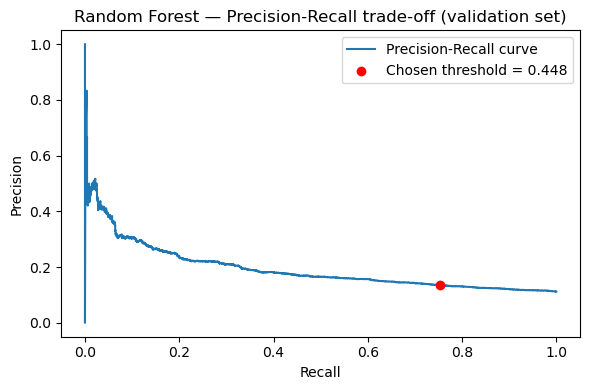

--- Random Forest: Default threshold (0.5) ---
PR-AUC:    0.1949
ROC-AUC:   0.6310
Precision: 0.1626
Recall:    0.4909
F1:        0.2443

--- Random Forest: Tuned threshold (0.448) ---
PR-AUC:    0.1949
ROC-AUC:   0.6310
Precision: 0.1343
Recall:    0.7338
F1:        0.2271



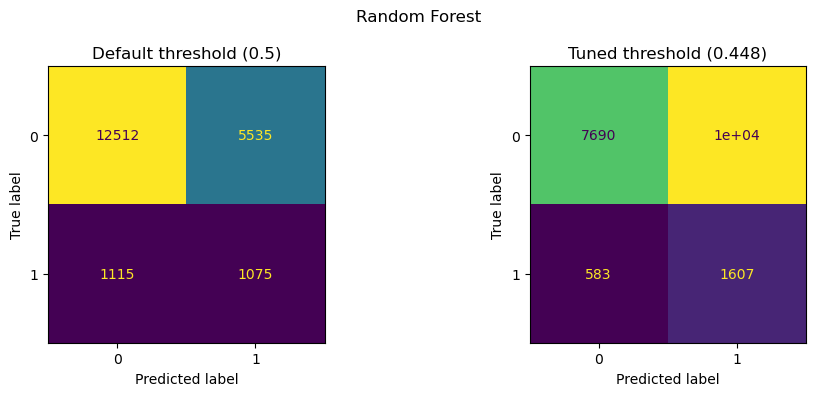

In [10]:
rf_final_model, rf_summary = tune_and_evaluate(
    "Random Forest", rf_search, X_train, y_train, X_test, y_test, patient_nbr_train
)

## 5. Feature Importance / Coefficients (supports Part H interpretability discussion)

Reuses the D020 argument: because PCA was rejected in favour of retaining named,
one-hot/ordinal features, both tuned models here can attribute a prediction to a specific
named clinical factor.

In [11]:
feature_names = X_train.columns.tolist()

# Logistic Regression coefficients
lr_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_final_model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
print("Top 10 Logistic Regression coefficients by absolute magnitude:")
print(lr_coef_df.head(10).to_string(index=False))

print()

# Random Forest feature importances
rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_final_model.feature_importances_,
}).sort_values("importance", ascending=False)
print("Top 10 Random Forest feature importances:")
print(rf_importance_df.head(10).to_string(index=False))

Top 10 Logistic Regression coefficients by absolute magnitude:
                          feature  coefficient
            num__number_inpatient     0.389392
    nom__diag_1_group_Respiratory    -0.197391
nom__medical_specialty_Cardiology    -0.176521
                         ord__age     0.067995
      nom__diag_1_group_Digestive    -0.065994
            num__number_emergency     0.057229
       nom__diag_1_group_Diabetes     0.054310
   nom__medical_specialty_Missing     0.048362
         nom__diag_1_group_Injury     0.046563
    nom__diag_1_group_Circulatory     0.042119

Top 10 Random Forest feature importances:
                          feature  importance
            num__number_inpatient    0.740716
            num__number_emergency    0.074344
                         ord__age    0.068417
    nom__diag_1_group_Respiratory    0.019239
           num__number_outpatient    0.016159
nom__medical_specialty_Cardiology    0.008939
    nom__diag_1_group_Circulatory    0.008153
       no

## 6. Save Artifacts for Part G (Ensemble) and Part H (Evaluation)

Persisting the tuned pipelines and metrics so Part G can load them directly, and so Part F's
"after optimisation" numbers are guaranteed to match what is reported in the notebook.

In [12]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

joblib.dump(lr_final_model, "../models/logistic_regression_tuned.joblib")
joblib.dump(rf_final_model, "../models/random_forest_tuned.joblib")

combined_summary = {
    "logistic_regression": lr_summary,
    "random_forest": rf_summary,
}

with open("../results/lr_rf_tuned_summary.json", "w") as f:
    json.dump(combined_summary, f, indent=2)

print("Saved:")
print(" - ../models/logistic_regression_tuned.joblib")
print(" - ../models/random_forest_tuned.joblib")
print(" - ../results/lr_rf_tuned_summary.json")
print()
print(json.dumps(combined_summary, indent=2))

Saved:
 - ../models/logistic_regression_tuned.joblib
 - ../models/random_forest_tuned.joblib
 - ../results/lr_rf_tuned_summary.json

{
  "logistic_regression": {
    "model": "Logistic Regression",
    "best_params": {
      "C": 0.011526449540315618,
      "l1_ratio": 0.18182496720710062,
      "penalty": "l1"
    },
    "cv_pr_auc_grouped": 0.19254161527087926,
    "chosen_threshold": 0.43512174741300497,
    "test_pr_auc": 0.19150248599279746,
    "test_roc_auc": 0.6266241774078998,
    "test_precision_default": 0.17091104734576756,
    "test_recall_default": 0.4351598173515982,
    "test_precision_tuned": 0.1288329860077404,
    "test_recall_tuned": 0.7904109589041096,
    "test_f1_tuned": 0.22155382055548445
  },
  "random_forest": {
    "model": "Random Forest",
    "best_params": {
      "class_weight": "balanced",
      "max_depth": 5.0,
      "max_features": 0.5,
      "min_samples_leaf": 9.0,
      "min_samples_split": 15.0,
      "n_estimators": 341.0
    },
    "cv_pr_auc_g

In [13]:
## 7. Status and Next Steps

**What this notebook has done:**
- Reconstructed `patient_nbr` for the training rows (matching D022's method) so Part F's CV
  is grouped/leakage-safe for all three models, not just XGBoost
- Ran `RandomizedSearchCV` (grouped, PR-AUC-scored) for Logistic Regression (`C`, `penalty`,
  `l1_ratio`) and Random Forest (`n_estimators`, `max_depth`, `min_samples_split`,
  `min_samples_leaf`, `max_features`, `class_weight` incl. `balanced_subsample`)
- Tuned decision thresholds via F2 on a grouped validation split, matching D022's healthcare
  justification
- Evaluated both tuned models once on the held-out test set
- Saved fitted pipelines and a results summary for Part G/H

**Fill in after running (per Section 23's experimental-results policy — do not write these
before the cells above have actually executed):**
- [ ] Record actual CV PR-AUC and test PR-AUC/ROC-AUC for both models in the handover doc as a
      new decision block (e.g. D023)
- [ ] State explicitly whether tuning meaningfully improved each model, or whether — as with
      D022's XGBoost result — the raw grouped-vs-ungrouped CV comparison isn't a clean delta
- [ ] If Random Forest's tuned PR-AUC is still clearly behind LR and XGBoost, this directly
      informs Part G's "best two of three" ensemble selection — flag it rather than downplaying it
- [ ] Confirm with Person B whether `xgboost-advanced-optimisation` has been merged to `main`
      before combining results across all three models in Part G

SyntaxError: unterminated string literal (detected at line 9) (385392940.py, line 9)

In [14]:
from sklearn.ensemble import RandomForestClassifier as _RFC

# Reconstruct the untuned baseline exactly as D021 would have specified it:
# class_weight='balanced', all other params at sklearn defaults (unbounded depth).
rf_untuned = _RFC(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_untuned.fit(X_train, y_train)

untuned_train_proba = rf_untuned.predict_proba(X_train)[:, 1]
untuned_test_proba = rf_untuned.predict_proba(X_test)[:, 1]

tuned_train_proba = rf_final_model.predict_proba(X_train)[:, 1]
tuned_test_proba = rf_final_model.predict_proba(X_test)[:, 1]

diagnostic = pd.DataFrame({
    "Configuration": ["Untuned (unbounded depth)", "Tuned (max_depth=5, ...)"],
    "Train PR-AUC": [
        average_precision_score(y_train, untuned_train_proba),
        average_precision_score(y_train, tuned_train_proba),
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, untuned_test_proba),
        average_precision_score(y_test, tuned_test_proba),
    ],
})
diagnostic["Train-Test Gap"] = diagnostic["Train PR-AUC"] - diagnostic["Test PR-AUC"]

print(diagnostic.to_string(index=False))
print()
print("A large gap for 'Untuned' that shrinks substantially for 'Tuned' supports the")
print("overfitting explanation for RF's large tuning improvement. Record this table's")
print("actual output in the report/decision log — do not assume the hypothesis holds")
print("without checking the numbers above.")

            Configuration  Train PR-AUC  Test PR-AUC  Train-Test Gap
Untuned (unbounded depth)      0.645864     0.120015        0.525849
 Tuned (max_depth=5, ...)      0.206730     0.194896        0.011833

A large gap for 'Untuned' that shrinks substantially for 'Tuned' supports the
overfitting explanation for RF's large tuning improvement. Record this table's
actual output in the report/decision log — do not assume the hypothesis holds
without checking the numbers above.


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression as _LR

count_cols = ["num__number_inpatient", "num__number_emergency", "num__number_outpatient"]
diag_group_cols = [c for c in X_train.columns if c.startswith("nom__diag_1_group_")]

missing_count_cols = [c for c in count_cols if c not in X_train.columns]
if missing_count_cols:
    print(f"NOTE: expected count columns not found: {missing_count_cols}")
    print("Available columns containing 'number_':", [c for c in X_train.columns if "number_" in c])
else:
    def build_engineered_features(X):
        X_eng = X.copy()
        # log1p transform of right-skewed count variables (values are already scaled by
        # StandardScaler upstream; log1p is applied to the raw scaled value as a monotonic
        # reshaping, not a re-derivation from raw counts)
        for c in count_cols:
            X_eng[f"{c}_log1p"] = np.log1p(X_eng[c] - X_eng[c].min())  # shift to non-negative before log1p
        # interaction: number_inpatient x each diag_1_group dummy
        for dc in diag_group_cols:
            X_eng[f"inpatient_x_{dc}"] = X_eng["num__number_inpatient"] * X_eng[dc]
        return X_eng

    X_train_eng = build_engineered_features(X_train)

    lr_plain = _LR(
        C=lr_search.best_params_["C"],
        penalty=lr_search.best_params_["penalty"],
        l1_ratio=lr_search.best_params_.get("l1_ratio"),
        class_weight="balanced",
        solver="saga",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )
    lr_engineered = _LR(
        C=lr_search.best_params_["C"],
        penalty=lr_search.best_params_["penalty"],
        l1_ratio=lr_search.best_params_.get("l1_ratio"),
        class_weight="balanced",
        solver="saga",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    plain_scores = cross_val_score(
        lr_plain, X_train, y_train, groups=patient_nbr_train,
        cv=cv, scoring="average_precision", n_jobs=-1,
    )
    engineered_scores = cross_val_score(
        lr_engineered, X_train_eng, y_train, groups=patient_nbr_train,
        cv=cv, scoring="average_precision", n_jobs=-1,
    )

    print(f"LR (tuned params, original features):    PR-AUC = {plain_scores.mean():.4f} (+/- {plain_scores.std():.4f})")
    print(f"LR (tuned params, + interactions/log1p):  PR-AUC = {engineered_scores.mean():.4f} (+/- {engineered_scores.std():.4f})")
    print(f"Difference: {engineered_scores.mean() - plain_scores.mean():+.4f}")
    print()
    print("Interpretation guide:")
    print("- Meaningful positive difference -> feature representation, not just hyperparameters,")
    print("  was a real bottleneck for LR. Worth folding into Part D's pipeline properly.")
    print("- Negligible/negative difference -> LR's ceiling is genuinely close to 0.192 given")
    print("  this feature set; further engineering effort is better spent elsewhere (e.g. RF/XGBoost")
    print("  already outperform LR and don't need this fix).")

LR (tuned params, original features):    PR-AUC = 0.1925 (+/- 0.0077)
LR (tuned params, + interactions/log1p):  PR-AUC = 0.1919 (+/- 0.0077)
Difference: -0.0007

Interpretation guide:
- Meaningful positive difference -> feature representation, not just hyperparameters,
  was a real bottleneck for LR. Worth folding into Part D's pipeline properly.
- Negligible/negative difference -> LR's ceiling is genuinely close to 0.192 given
  this feature set; further engineering effort is better spent elsewhere (e.g. RF/XGBoost
  already outperform LR and don't need this fix).
